<h2>Script for analysing miRNA validation</h2>

In [1]:
import os
import sys
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import scipy.stats as stats 

sys.path.append(os.path.abspath("./stats/OutcomePrediction/utils"))
import aimtbi_constants #constants for AIMTBI project - used for example to clean questionnaire data
import aimtbi_helper_functions #Custom functions used across AIM-TBI project

%load_ext autoreload
%autoreload 2

<h3>Loading in the data and data cleaning</h3>

In [2]:
#Loading validation data
data_val = pd.read_excel('/users/koen_phd/Documents/phd/biomarkers/mirna/rna_isolatie_lijst_05_03.xlsx', sheet_name='results_compact')
#Cleaning sample_id column in the data used for validation so that we can match it with the tmm normalized data
data_val['sample_id'] = data_val['sample_id'].astype(str).str.replace('_', '-').apply(lambda x: x[0:5])
#loading in available clinical data
complete_data = pd.read_excel('/users/koen_phd/documents/phd/biomarkers/outcome prediction/cleaned_data_09_12_24.xlsx')
#Only keeping the data we are interested in
complete_data = complete_data[['lab_id', 'record_id', 'group', 'age', 'mri_id', 'gender', 'ct_abnormalities', 'conclusion_radiologist_ct', 'marshall_score', 'injury_mechanism', 'gcs', 'loc', 'pta', 'hospital_admission', 'ais_head', 'iss', 'alcohol_intoxication', 'gose_6_months', 'previous_tbi', 'time_to_v1_minutes', 'nfl_conc', 'nfl_conc_v2', 'il6_conc', 'il6_conc_v2', 'il8_conc_v2', 'il8_conc', 'il10_conc', 'il10_conc_v2', 'time_category', 'uchl1', 'gfap']]
#Loading in TMM normalized data obtained from Edger using sRNA bench.
data_tmm_normalized = pd.read_csv('/users/koen_phd/documents/phd/biomarkers/mirna/data_tmm_11_04.csv', sep='\t', index_col='name') #file with all samples used for HC vs mTBI DE analysis
data_tmm_normalized = data_tmm_normalized.T
data_tmm_normalized['sample_id'] = data_tmm_normalized.index.str.slice(7, 10).astype(int)
data_tmm_normalized = data_tmm_normalized.add_suffix('_dx')

data_tmm_normalized_ct = pd.read_csv('/users/koen_phd/Documents/phd/biomarkers/mirna/mature_sense_minExpr5_RCadj_edger_TMMnormTable.csv', sep='\t', index_col='name') #file will all samples for CT+ vs CT- DE analysis
data_tmm_normalized_ct = data_tmm_normalized_ct.T
data_tmm_normalized_ct['sample_id'] = data_tmm_normalized_ct.index.str.slice(7, 10).astype(int)
data_tmm_normalized_ct = data_tmm_normalized_ct.add_suffix('_ct')

data_tmm_normalized_cr = pd.read_csv('/users/koen_phd/Documents/phd/biomarkers/mirna/TMMnorm_CR_vs_IR.csv', sep='\t', index_col='name') #file with all samples for CR vs IR DE analysis
data_tmm_normalized_cr = data_tmm_normalized_cr.T
data_tmm_normalized_cr['sample_id'] = data_tmm_normalized_cr.index.str.slice(7, 10).astype(int)
data_tmm_normalized_cr = data_tmm_normalized_cr.add_suffix('_gose')

#merging the separate datasets into a single dataframe
temp_data = pd.merge(complete_data, data_val, left_on='lab_id', right_on='sample_id', how='right')
temp_data_v2 = pd.merge(temp_data, data_tmm_normalized, left_on='Isolatie', right_on='sample_id_dx', how='left' )
temp_data_v3 = pd.merge(temp_data_v2, data_tmm_normalized_ct, left_on='Isolatie', right_on='sample_id_ct', how='left' )
analysis_data = pd.merge(temp_data_v3, data_tmm_normalized_cr, left_on='Isolatie', right_on='sample_id_gose', how='left' ) #final dataframe with all the data we need for the analysis

#Cleaning the analysis data frame using some functions from the aimtbi_helper_functions library. These functions have been tested and used all studies using these biomarekrs
analysis_data = aimtbi_helper_functions.clean_concentrations(analysis_data, ['il6', 'il8', 'il10', 'nfl'], aimtbi_constants.biomarker_llod)
aimtbi_helper_functions.clean_poct_data(analysis_data)
analysis_data['pta_dicho'] = analysis_data['pta'].apply(lambda  x: 1 if x == 0 else 0) # 1 if PTA, 0 if PTA no or possible ('not witnessed)
analysis_data['loc_dicho'] = analysis_data['loc'].apply(lambda x: 1 if x == 0 else 0) # 1 if loc, 0 if loc no or possible ('not witnessed)
analysis_data['ct_dicho'] = analysis_data['marshall_score'].apply(lambda x: 1 if x > 1 else 0) # 1 = CT abnormality, 0 - no CT abnormality
analysis_data['extracranial_dicho'] = analysis_data[['ais_head', 'iss']].apply(lambda x: aimtbi_helper_functions.calculate_extracranial(x[0], x[1]), axis=1)
record_ids_to_change_manually = [12, 81, 83, 96, 149, 208] #Refer back to kynurenine study why these are the only ones that need to be changed manually
analysis_data.loc[analysis_data['record_id'].isin(record_ids_to_change_manually), 'extracranial_dicho'] = 1
analysis_data['gose_dichotimized'] = analysis_data['gose_6_months'].apply(lambda x: aimtbi_helper_functions.dichotimizeOutcome(x)) #0 = incomplete recovery, 1 = complete recovery, 99 = outcome unknown (for healthy controls)

#saving cleaned dataset - this data set is loaded in the next script for analysis of TMM normalized RNA-Seq data
analysis_data.to_excel(r'/users/koen_phd/documents/phd/biomarkers/mirna/analysis_data_15_05.xlsx')


<h3>Impute missing data</h3>
<p>There are relatively few missing data points for hsa-miR-206. These can be imputed. Due to a detectability rate below 20% for hsa-miR-129-5p no imputation will be performed</p>

In [4]:
#Defining functions for the imputation
from sklearn.experimental import enable_iterative_imputer  # This import is required
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer

def create_imputer(method='knn', n_neighbors=5):
    """
    Create an imputer object based on the specified method.
    
    Parameters
    ----------
    method : str
        Imputation method ('mean', 'median', 'knn', or 'iterative')
    n_neighbors : int
        Number of neighbors to use for KNN imputation
        
    Returns
    -------
    sklearn imputer object
    """
    
    if method == 'mean':
        return SimpleImputer(strategy='mean')
    elif method == 'median':
        return SimpleImputer(strategy='median')
    elif method == 'knn':
        return KNNImputer(n_neighbors=n_neighbors)
    elif method == 'iterative':
        return IterativeImputer(random_state=42, max_iter=10)
    else:
        raise ValueError("Method must be one of: 'mean', 'median', 'knn', or 'iterative'")

def fit_imputer(train_data, columns_to_impute, method='knn', n_neighbors=5):
    """
    Fit an imputer on the training data.
    
    Parameters
    ----------
    train_data : pandas DataFrame
        The training data containing missing values
    columns_to_impute : list
        List of column names to perform imputation on
    method : str
        Imputation method ('mean', 'median', 'knn', or 'iterative')
    n_neighbors : int
        Number of neighbors to use for KNN imputation
        
    Returns
    -------
    tuple
        (fitted imputer, list of column names)
    """
    # Validate columns
    if not all(col in train_data.columns for col in columns_to_impute):
        missing_cols = [col for col in columns_to_impute if col not in train_data.columns]
        raise ValueError(f"Columns not found in data: {missing_cols}")
    
    # Create and fit the imputer
    imputer = create_imputer(method, n_neighbors)
    imputer.fit(train_data[columns_to_impute])
    
    return imputer, columns_to_impute

def transform_with_imputer(data, imputer, columns_to_impute, group):
    """
    Apply a fitted imputer to new data.
    
    Parameters
    ----------
    data : pandas DataFrame
        The data to impute
    imputer : sklearn imputer object
        The fitted imputer
    columns_to_impute : list
        List of column names to perform imputation on
        
    Returns
    -------
    pandas DataFrame
        DataFrame with imputed values
    """
    # Create a copy of the data
    data_imputed = data.copy()
    
    # Print initial missing values info
    print(f"\nMissing values before imputation for {group} data:")
    print(data[columns_to_impute].isnull().sum())
    
    # Apply the imputer
    data_imputed[columns_to_impute] = imputer.transform(data[columns_to_impute])
    
    # Print final missing values info
    print(f"\nMissing values after imputation for {group} data:")
    print(data_imputed[columns_to_impute].isnull().sum())
    print('--------------------------------')
    
    return data_imputed

In [5]:
#Defining the separate training and validation sets. The Imputer will only be trained on the oringinal data to maintain the integrity of the validation set.
original_data = analysis_data.iloc[0:64] #54 mTBI samples and 10 HC
validation_data = analysis_data.iloc[64:] #31 samples

columns_to_impute = ['hsa_mir_206'] #As previously mentioned only imputing hsa-miR-206

imputer, cols = fit_imputer(original_data, columns_to_impute, method='knn') #Training imputer on original data (discovery cohort)

# 2. Then apply it to both training and validation sets
train_imputed = transform_with_imputer(original_data, imputer, cols, 'original')
val_imputed = transform_with_imputer(validation_data, imputer, cols, 'validation')

#Adding the imputed data onto the original data frame
analysis_data = pd.concat([train_imputed, val_imputed])

#Seperating dataframe into separate groups note that this is across all data so original plus validation cohort
ct_pos = analysis_data.loc[(analysis_data['group'] == 1) & (analysis_data['ct_abnormalities'] == 1)]
ct_neg = analysis_data.loc[(analysis_data['group'] == 1) & (analysis_data['ct_abnormalities'] == 0)]
hc = analysis_data.loc[analysis_data['group'] == 0]


Missing values before imputation for original data:
hsa_mir_206    11
dtype: int64

Missing values after imputation for original data:
hsa_mir_206    0
dtype: int64
--------------------------------

Missing values before imputation for validation data:
hsa_mir_206    7
dtype: int64

Missing values after imputation for validation data:
hsa_mir_206    0
dtype: int64
--------------------------------


<H3>Analysis of Clincical plus demographical data in Original cohort</H3>

In [7]:

#Defining characteristics for table 1
characteristics = {
    'age': ['likert'], # continuous variable
    'gender':['ord', [1]], #1 = female so represents %female
    'pta_dicho':['ord', [1]], #1 = YES, 0 = possibly or no
    'loc_dicho':['ord', [1]], #1 = YES, 0 = possibly
    'extracranial_dicho':['ord', [1]], #0 = presence of extracranial injury
    'ais_head':['cont'], #ordinal scale
    'gcs':['spec', [13, 14, 15], ['13', '14', '15']], 
    'alcohol_intoxication':['ord', [1]], #1 = Yes, at time of admission
    'injury_mechanism':['spec', [1, 2, 3, 4, 5, 6, 7, 8, 9], ['MVA', 'Bicycle', 'Fall', 'Sport', 'Other']],
    'ct_dicho':['ord', [1]], #1 = CT abnormality i.e., Marshall score >0
    'gose_dichotimized':['ord', [1]], #1 = complete recovery,
    'time_to_v1_minutes':['likert']
}

#Seperating original data from validation cohort
mtbi_org = analysis_data.iloc[0:64, :].loc[analysis_data['group'] == 1]
#Original data CT plus
mtbi_org_plus = mtbi_org.loc[mtbi_org['ct_abnormalities'] == 1]
#Origianl data CT negative
mtbi_org_minus = mtbi_org.loc[mtbi_org['ct_abnormalities'] == 0]
#Due to being too lazy to fix function have to use CR and IR naming convention.
groupDataframes = {'CR': mtbi_org_minus, 'IR': mtbi_org_plus}
groups = ['CR', 'IR']

characteristicTable = aimtbi_helper_functions.createCharacteristicTable(characteristics, groups, groupDataframes)
display(characteristicTable)

,CR,IR
variables,,
age,27,27
gender,27,27
pta_dicho,27,27
loc_dicho,27,27
extracranial_dicho,27,27
ais_head,27,27
gcs,27,27
alcohol_intoxication,27,27
injury_mechanism,27,27


,CR,IR
Variables,,
count,27,27
age,"46.0 [25.0, 57.5]","48.0 [29.0, 58.5]"
gender,14 (51.9%),12 (44.4%)
pta_dicho,21 (77.8%),24 (88.9%)
loc_dicho,10 (37.0%),20 (74.1%)
extracranial_dicho,9 (33.3%),17 (63.0%)
ais_head,2.0 0.0 (2.0-2.0),3.0 1.0 (2.0-4.0)
13,0 (0.0%),3 (11.1%)
14,8 (29.6%),11 (40.7%)


In [8]:
def calculating_chi_square(dataframe, column_1, column_2):
    contingency_table = pd.crosstab(dataframe[column_1], dataframe[column_2])
    stat, p, dof, expected = stats.chi2_contingency(contingency_table)
    print(f'{column_1} by {column_2}')
    print(f'Chi-square statistic: {stat}, (p = {p}), (dof = {dof}) \n')
    print(expected)
    return

print('original cohort')
print(stats.mannwhitneyu(mtbi_org.loc[mtbi_org['ct_abnormalities'] == 0, ['age']], mtbi_org.loc[mtbi_org['ct_abnormalities'] == 1, ['age']]))
for column in ['gender', 'pta_dicho', 'loc_dicho', 'alcohol_intoxication', 'gose_dichotimized', 'extracranial_dicho']:
    calculating_chi_square(mtbi_org, column, 'ct_abnormalities')

original cohort
MannwhitneyuResult(statistic=array([336.5]), pvalue=array([0.63412368]))
gender by ct_abnormalities
Chi-square statistic: 0.07417582417582418, (p = 0.7853510769129868), (dof = 1) 

[[14. 14.]
 [13. 13.]]
pta_dicho by ct_abnormalities
Chi-square statistic: 0.5333333333333333, (p = 0.4652088184521417), (dof = 1) 

[[ 4.5  4.5]
 [22.5 22.5]]
loc_dicho by ct_abnormalities
Chi-square statistic: 6.074999999999999, (p = 0.013710830078133255), (dof = 1) 

[[12. 12.]
 [15. 15.]]
alcohol_intoxication by ct_abnormalities
Chi-square statistic: 0.0, (p = 1.0), (dof = 1) 

[[18.5 18.5]
 [ 8.5  8.5]]
gose_dichotimized by ct_abnormalities
Chi-square statistic: 4.7668965517241375, (p = 0.02901207863209926), (dof = 1) 

[[12.5 12.5]
 [14.5 14.5]]
extracranial_dicho by ct_abnormalities
Chi-square statistic: 3.634615384615385, (p = 0.05658967848755084), (dof = 1) 

[[14. 14.]
 [13. 13.]]


In [8]:
mtbi_org.loc[mtbi_org['group'] == 1, 'time_to_v1_minutes'].describe()

count      54.000000
mean      180.740741
std       206.085454
min        10.000000
25%        73.500000
50%       154.500000
75%       193.000000
max      1290.000000
Name: time_to_v1_minutes, dtype: float64

In [9]:
print(stats.mannwhitneyu(mtbi_org.loc[mtbi_org['ct_abnormalities'] == 0, ['time_to_v1_minutes']], mtbi_org.loc[mtbi_org['ct_abnormalities'] == 1, ['time_to_v1_minutes']]))

MannwhitneyuResult(statistic=array([356.5]), pvalue=array([0.89675262]))


In [9]:
analysis_data['dataset'] = 0  # Initialize all rows as 0
analysis_data.loc[64:, 'dataset'] = 1
mtbi_org = analysis_data.iloc[0:64, :].loc[analysis_data['group'] == 1]
mtbi_org_plus = mtbi_org.loc[mtbi_org['ct_abnormalities'] == 1]
mtbi_org_minus = mtbi_org.loc[mtbi_org['ct_abnormalities'] == 0]
mtbi_val = analysis_data.iloc[65:]
groupDataframes = {'CR': mtbi_org, 'IR': mtbi_val}
groups = ['CR', 'IR']

characteristicTable = aimtbi_helper_functions.createCharacteristicTable(characteristics, groups, groupDataframes)
display(characteristicTable)

,CR,IR
variables,,
age,54,31
gender,54,31
pta_dicho,54,31
loc_dicho,54,31
extracranial_dicho,54,31
ais_head,54,31
gcs,54,31
alcohol_intoxication,54,31
injury_mechanism,54,31


,CR,IR
Variables,,
count,54,31
age,"48.0 [26.75, 58.0]","58.0 [49.0, 68.5]"
gender,26 (48.1%),8 (25.8%)
pta_dicho,45 (83.3%),21 (67.7%)
loc_dicho,30 (55.6%),16 (51.6%)
extracranial_dicho,26 (48.1%),18 (58.1%)
ais_head,2.0 1.0 (2.0-4.0),2.0 0.0 (2.0-3.0)
13,3 (5.6%),0 (0.0%)
14,19 (35.2%),11 (35.5%)


In [10]:
print('original vs validation cohort')
print(stats.mannwhitneyu(mtbi_org['age'], mtbi_val['age']))
for column in ['gender', 'pta_dicho', 'loc_dicho', 'alcohol_intoxication', 'gose_dichotimized']:
    calculating_chi_square(analysis_data.loc[analysis_data['group'] == 1], column, 'dataset')

original vs validation cohort
MannwhitneyuResult(statistic=575.0, pvalue=0.016907335250390815)
gender by dataset
Chi-square statistic: 2.5597747432306246, (p = 0.10961420066516042), (dof = 1) 

[[32.02325581 18.97674419]
 [21.97674419 13.02325581]]
pta_dicho by dataset
Chi-square statistic: 1.707728717523494, (p = 0.19128032315759036), (dof = 1) 

[[11.93023256  7.06976744]
 [42.06976744 24.93023256]]
loc_dicho by dataset
Chi-square statistic: 0.0, (p = 1.0), (dof = 1) 

[[24.48837209 14.51162791]
 [29.51162791 17.48837209]]
alcohol_intoxication by dataset
Chi-square statistic: 4.332915088383839, (p = 0.0373821719676501), (dof = 1) 

[[41.44186047 24.55813953]
 [12.55813953  7.44186047]]
gose_dichotimized by dataset
Chi-square statistic: 0.9018928120490615, (p = 0.3422746852242418), (dof = 1) 

[[27.62790698 16.37209302]
 [26.37209302 15.62790698]]


In [11]:
print('original  mTBI vs HC')
print(stats.mannwhitneyu(mtbi_org['age'], analysis_data.loc[analysis_data['group'] == 0]['age']))
print(mtbi_org['gender'].value_counts())
print(analysis_data.loc[analysis_data['group'] == 0]['gender'].value_counts())
for column in ['gender', 'pta_dicho', 'loc_dicho', 'alcohol_intoxication', 'gose_dichotimized']:
    calculating_chi_square(analysis_data.iloc[0:64, :], column, 'group')

original  mTBI vs HC
MannwhitneyuResult(statistic=248.5, pvalue=0.6976960367857437)
0    28
1    26
Name: gender, dtype: int64
1    5
0    5
Name: gender, dtype: int64
gender by group
Chi-square statistic: 0.0, (p = 1.0), (dof = 1) 

[[ 5.15625 27.84375]
 [ 4.84375 26.15625]]
pta_dicho by group
Chi-square statistic: 24.219917695473253, (p = 8.5938917131448e-07), (dof = 1) 

[[ 2.96875 16.03125]
 [ 7.03125 37.96875]]
loc_dicho by group
Chi-square statistic: 8.345562817719681, (p = 0.0038663037910599313), (dof = 1) 

[[ 5.3125 28.6875]
 [ 4.6875 25.3125]]
alcohol_intoxication by group
Chi-square statistic: 0.0, (p = 1.0), (dof = 0) 

[[37.]
 [17.]]
gose_dichotimized by group
Chi-square statistic: 3.2263907632328688, (p = 0.07246022217846676), (dof = 1) 

[[ 4.0625 21.9375]
 [ 5.9375 32.0625]]


In [12]:
#calculating the head CT lesion types for each cohort

injury_type_map = {
    1.0: 'Contusion',
    2.0: 'EDH',
    3.0: 'SAB',
    4.0: 'SDH',
    5.0: 'Parenchymal bleed'
    }

print('discovery cohort')
print(mtbi_org['ct_injury_type_1'].value_counts().rename(injury_type_map))
print('\n')
print('validation cohort')

print(mtbi_val['ct_injury_type_1'].value_counts().rename(injury_type_map))

discovery cohort
SAB                  10
Contusion             8
SDH                   4
EDH                   3
Parenchymal bleed     2
Name: ct_injury_type_1, dtype: int64


validation cohort
SAB          8
Contusion    4
SDH          3
Name: ct_injury_type_1, dtype: int64


<h4>Testing distribution</h4>

Shapiro test for hsa_mir_129 at timepoint 1:
ShapiroResult(statistic=0.8055784702301025, pvalue=5.197598147788085e-05)


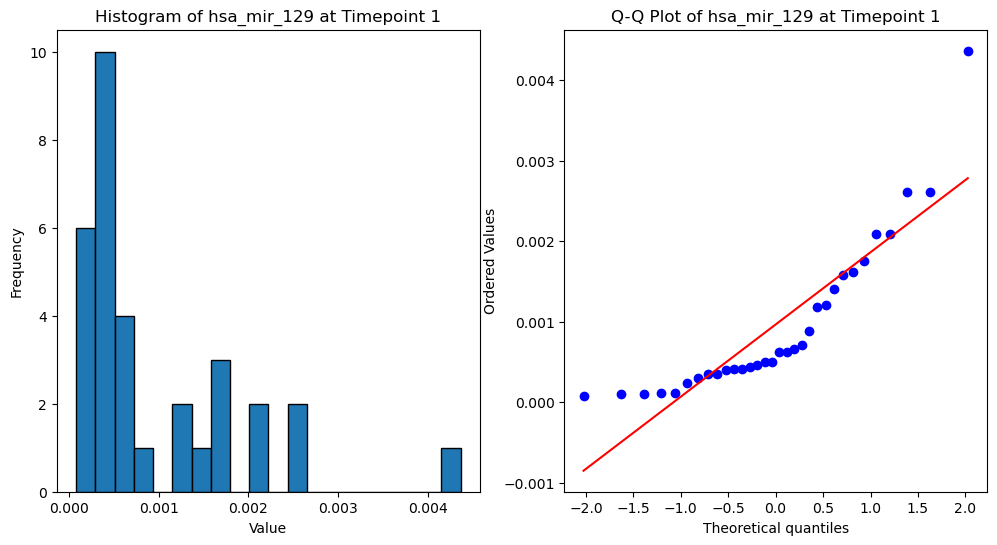

Shapiro test for hsa_mir_193 at timepoint 1:
ShapiroResult(statistic=0.5272002220153809, pvalue=4.651915534232458e-16)


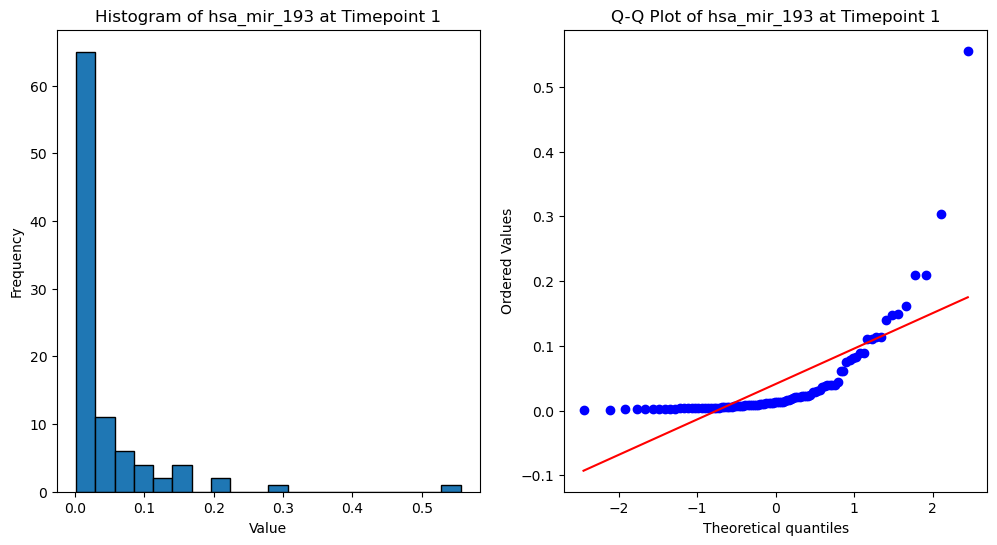

Shapiro test for hsa_mir_206 at timepoint 1:
ShapiroResult(statistic=0.3454270362854004, pvalue=1.0136960888060517e-18)


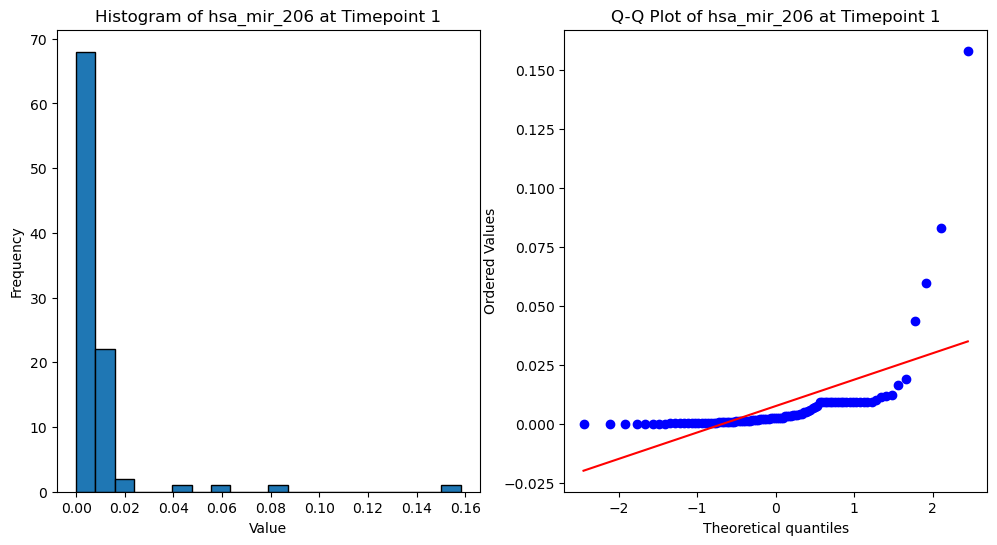

In [13]:
mirna_list = ['hsa_mir_129', 'hsa_mir_193', 'hsa_mir_206']

for mirna in mirna_list:
    temp = analysis_data.loc[analysis_data[mirna].notna(), mirna]
    aimtbi_helper_functions.normalityCheckSingle(temp, mirna)

Shapiro test for hsa_mir_129_log at timepoint 1:
ShapiroResult(statistic=0.9622840285301208, pvalue=0.3167969286441803)


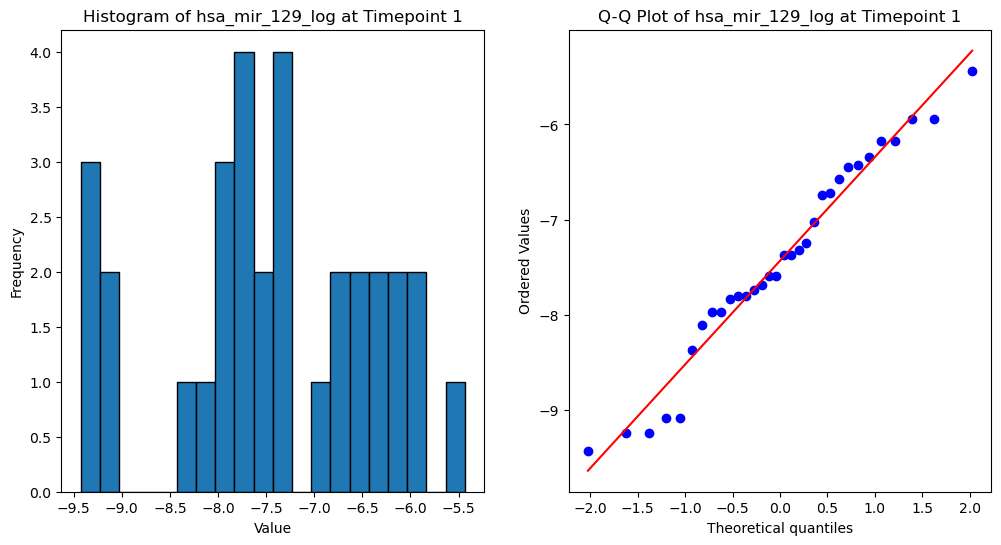

Shapiro test for hsa_mir_193_log at timepoint 1:
ShapiroResult(statistic=0.9706102609634399, pvalue=0.029593026265501976)


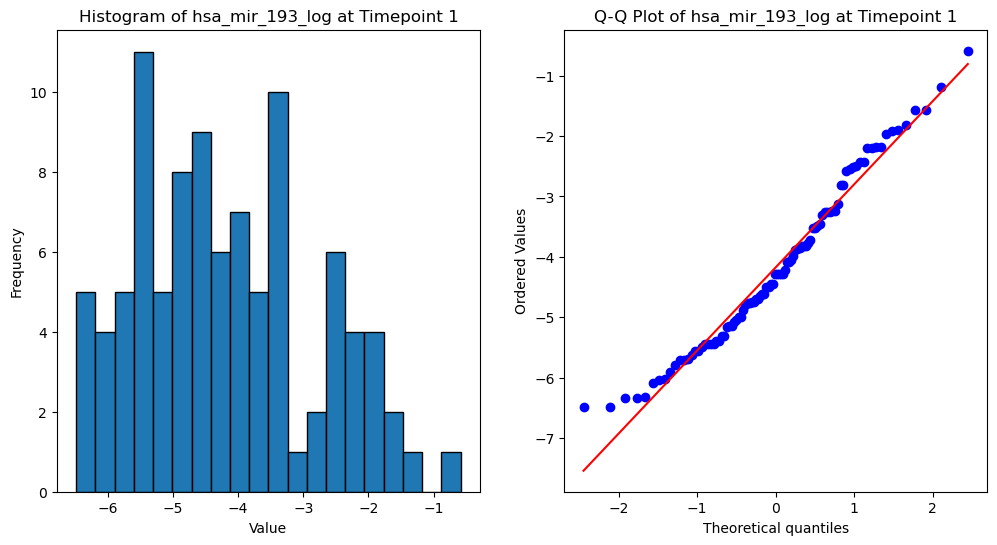

Shapiro test for hsa_mir_206_log at timepoint 1:
ShapiroResult(statistic=0.9726142287254333, pvalue=0.04177120327949524)


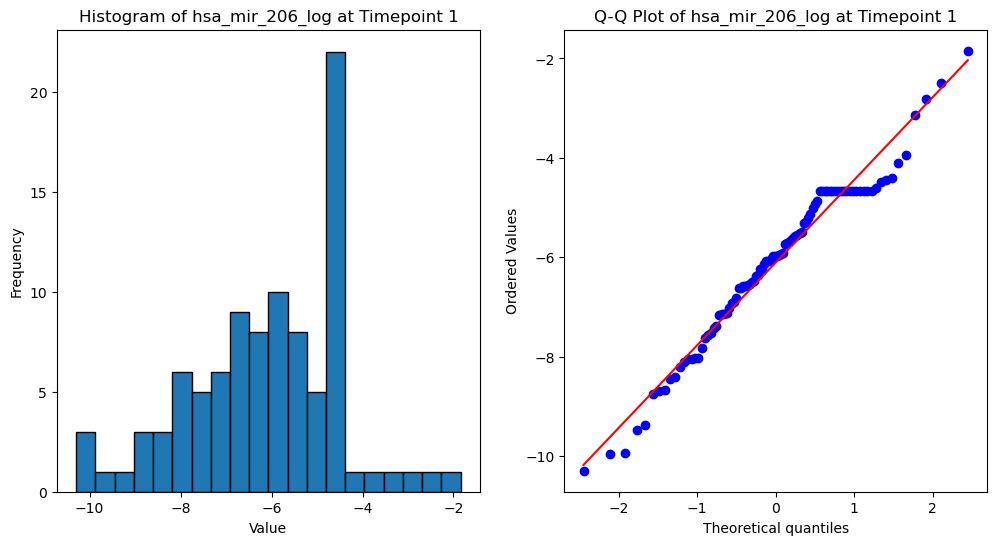

In [14]:
mirna_list = ['hsa_mir_129', 'hsa_mir_193', 'hsa_mir_206']

aimtbi_helper_functions.logTransform(analysis_data, mirna_list, suffix=['', ''])

mirna_list_log = ['hsa_mir_129_log', 'hsa_mir_193_log', 'hsa_mir_206_log']

for mirna in mirna_list_log:
    temp = analysis_data.loc[analysis_data[mirna].notna(), mirna]
    aimtbi_helper_functions.normalityCheckSingle(temp, mirna)

<h3>Testing group differences</h3>

In [15]:
def calculate_effect_size(group1, group2, paired=False):
    """
    Calculate Cohen's d effect size
    
    Parameters:
    -----------
    group1, group2 : array-like
        The two groups to compare
    paired : bool
        Whether the data is paired (True) or independent (False)
    """
    if paired:
        # For paired data, use the difference scores
        d = group1 - group2
        d_mean = np.mean(d)
        d_std = np.std(d, ddof=1)
        return d_mean / d_std if d_std != 0 else 0
    else:
        # For independent samples
        n1, n2 = len(group1), len(group2)
        var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
        # Pooled standard deviation
        pooled_sd = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
        return (np.mean(group1) - np.mean(group2)) / pooled_sd if pooled_sd != 0 else 0
    
def calculate_group_differences(group1, group2, biomarkers, headings = ['mtbi', 'hc']):
    """
    Calculate group differences using Welch's t-test and effect sizes.
    
    Parameters
    ----------
    group1, group2 : pandas DataFrame
        The two groups to compare
    biomarkers : list
        List of biomarker names to analyze
    headings : list
        Names of the two groups for output formatting
    
    Returns
    -------
    pandas DataFrame
        Results of the statistical analysis
    """
    from scipy import stats
    import numpy as np
    import pandas as pd
    
    results = []

    group1_size = len(group1)
    group2_size = len(group2)

    for biomarker in biomarkers:
        # Get non-missing values
        group1_temp = group1.loc[group1[biomarker].notna(), biomarker]
        group1_count = len(group1_temp)
        detection_rate_group1 = group1_count / group1_size
        
        group2_temp = group2.loc[group2[biomarker].notna(), biomarker]
        group2_count = len(group2_temp)
        detection_rate_group2 = group2_count / group2_size

        # Calculate medians and IQRs (keeping these as they're useful descriptive statistics)
        group1_median = group1_temp.median()
        group1_iqr = group1_temp.quantile(0.75) - group1_temp.quantile(0.25)
        group1_str = f"{group1_median:.4f} ({group1_iqr:.4f})"

        group2_median = group2_temp.median()
        group2_iqr = group2_temp.quantile(0.75) - group2_temp.quantile(0.25)
        group2_str = f"{group2_median:.4f} ({group2_iqr:.4f})"

        # Perform Welch's t-test
        t_stat, p_value = stats.ttest_ind(group1_temp, group2_temp, equal_var=False)
        mann_whitney_u, mann_whitney_p = stats.mannwhitneyu(group1_temp, group2_temp)
        
        # Calculate Cohen's d effect size
        cohens_d = calculate_effect_size(group1_temp, group2_temp, paired=False)
        
        # Format the result string with t-statistic instead of W
        result_string = f"{biomarker}: t={t_stat:.2f}, p={p_value:.3f}, d={cohens_d:.2f}"

        results.append({
            'Biomarker': biomarker,
            f"Detection {headings[0]}": detection_rate_group1,
            headings[0]: group1_str,
            f"Detection {headings[1]}": detection_rate_group2,
            headings[1]: group2_str,
            f"{headings[0]} vs {headings[1]}": result_string,
            # Add additional statistics that might be useful
            't_statistic': t_stat,
            'mann_whitney_u': mann_whitney_u,
            'mann_whitney_p': mann_whitney_p,
            'p_value': p_value,
            'cohens_d': cohens_d
            })
        
    return pd.DataFrame(results)

In [16]:
def calculate_group_differences_with_covariate(group1, group2, biomarkers, covariate="age", headings=['mtbi', 'hc']):
    """
    Calculate group differences using ANCOVA (adjusting for covariate) 
    along with descriptive statistics.

    Parameters
    ----------
    group1, group2 : pandas DataFrame
        The two groups to compare
    biomarkers : list
        List of biomarker names to analyze
    covariate : str
        Covariate to adjust for (e.g., 'age')
    headings : list
        Names of the two groups for output formatting
    
    Returns
    -------
    pandas DataFrame
        Results of the statistical analysis
    """
    import pandas as pd
    import numpy as np
    import statsmodels.api as sm
    from statsmodels.formula.api import ols

    results = []

    # Merge groups and add a group indicator
    group1 = group1.copy()
    group2 = group2.copy()
    group1['__group__'] = headings[0]
    group2['__group__'] = headings[1]
    data = pd.concat([group1, group2], axis=0)

    group1_size = len(group1)
    group2_size = len(group2)

    for biomarker in biomarkers:
        # Drop missing values for this biomarker and covariate
        temp = data[[biomarker, covariate, '__group__']].dropna()

        # Detection rates
        detection_rate_group1 = group1[biomarker].notna().mean()
        detection_rate_group2 = group2[biomarker].notna().mean()

        # Descriptives
        group1_temp = group1[biomarker].dropna()
        group2_temp = group2[biomarker].dropna()
        group1_str = f"{group1_temp.median():.4f} ({(group1_temp.quantile(0.75) - group1_temp.quantile(0.25)):.4f})"
        group2_str = f"{group2_temp.median():.4f} ({(group2_temp.quantile(0.75) - group2_temp.quantile(0.25)):.4f})"

        # ANCOVA model
        formula = f"{biomarker} ~ __group__ + {covariate}"
        model = ols(formula, data=temp).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)

        p_value = anova_table.loc["__group__", "PR(>F)"]
        f_value = anova_table.loc["__group__", "F"]

        results.append({
            'Biomarker': biomarker,
            f"Detection {headings[0]}": detection_rate_group1,
            headings[0]: group1_str,
            f"Detection {headings[1]}": detection_rate_group2,
            headings[1]: group2_str,
            f"{headings[0]} vs {headings[1]} (ANCOVA)": f"F={f_value:.2f}, p={p_value:.3f}",
            'F_statistic': f_value,
            'p_value': p_value
        })

    return pd.DataFrame(results)

In [17]:
#miRNA were chosen based on differential expression between HC and mTBI in the original cohort (rna-seq data)
#we are therefore interested if the RT-qPCR data of the miRNA are still differentially expressed between HC and mTBI in the discovery cohort
#Because of relatively few samples for miR-129 we will not use this miRNA for the analysis

mtbi_org = analysis_data.iloc[0:64, :].loc[analysis_data['group'] == 1]
hc = analysis_data.iloc[0:64, :].loc[analysis_data['group'] == 0]
comparison_table = calculate_group_differences(mtbi_org, hc, ['hsa_mir_193_log', 'hsa_mir_206_log'])
print('\n')
print(comparison_table.to_string(index=False))

#Next we are interested if miRNA data in the validation cohort are drastically different then data in the discovery cohort
mtbi_val = analysis_data.iloc[64:, :].loc[analysis_data['group'] == 1]
comparison_table = calculate_group_differences(mtbi_org, mtbi_val, ['hsa_mir_193_log', 'hsa_mir_206_log'])
print('\n')
print(comparison_table.to_string(index=False))







      Biomarker  Detection mtbi             mtbi  Detection hc               hc                               mtbi vs hc  t_statistic  mann_whitney_u  mann_whitney_p  p_value  cohens_d
hsa_mir_193_log             1.0 -4.0691 (1.7245)           1.0 -5.7082 (0.8548) hsa_mir_193_log: t=4.88, p=0.000, d=1.18     4.879782           453.0        0.000740 0.000087  1.178667
hsa_mir_206_log             1.0 -5.5902 (1.6988)           1.0 -7.5479 (0.7220) hsa_mir_206_log: t=4.44, p=0.001, d=1.31     4.436717           457.0        0.000546 0.000503  1.313153


      Biomarker  Detection mtbi             mtbi  Detection hc               hc                               mtbi vs hc  t_statistic  mann_whitney_u  mann_whitney_p  p_value  cohens_d
hsa_mir_193_log             1.0 -4.0691 (1.7245)           1.0 -4.3667 (2.2012) hsa_mir_193_log: t=0.76, p=0.451, d=0.17     0.759104           938.5        0.508477 0.450613  0.171068
hsa_mir_206_log             1.0 -5.5902 (1.6988)           1.0 -6.2530 

In [19]:
table_with_covariate = calculate_group_differences_with_covariate(mtbi_org, mtbi_val, ['hsa_mir_193_log', 'hsa_mir_206_log'], covariate='alcohol_intoxication')
print('\n')
print(table_with_covariate.to_string(index=False))







      Biomarker  Detection mtbi             mtbi  Detection hc               hc mtbi vs hc (ANCOVA)  F_statistic  p_value
hsa_mir_193_log             1.0 -4.0691 (1.7245)           1.0 -4.3667 (2.2012)     F=1.77, p=0.187     1.772913 0.186667
hsa_mir_206_log             1.0 -5.5902 (1.6988)           1.0 -6.2530 (3.4013)     F=8.96, p=0.004     8.959915 0.003635


<h3>Plotting validation data</h3>

In [228]:
plt.rcParams['font.family'] = 'helvetica'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'

def lighten_color(color, amount=0.5):
    """
    Lightens the given color by mixing it with white.
    Input can be matplotlib color string, hex string, or RGB tuple.
    amount=0 returns original color, amount=1 returns white.
    """
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = np.array(mc.to_rgb(c))
    white = np.array([1, 1, 1])
    return tuple((1 - amount) * c + amount * white)

def plot_boxplot(dataframes, dataframe_names, biomarkers, margin_dict = {'left': 0.1, 'right': 0.04, 'top': 0.05, 'bottom': 0.05, 'h_spacing': 0.05, 'v_spacing': 0.06}, break_thresholds = None, colors = None, figsize = (200, 100), figsize_unit = 'mm', dpi=300, save=False, save_location = None,y_labels=None, titles=None):
    """
    Create plots with optional broken y-axes for biomarkers with outliers.
    
    Parameters:
    -----------
    dataframes : list of pandas.DataFrame
        List of dataframes containing the biomarker data
    dataframe_names : list of str
        List of names for each dataframe (will be used as x-axis labels)
    biomarkers : list of str
        List of biomarker column names to plot
    margin_dict : dict
        Dictionary containing margin settings
    break_thresholds : dict, optional
        Dictionary mapping biomarker names to their break thresholds
    colors : list, optional
        List of colors to use for each group
    figsize : tuple
        Figure size in specified units
    figsize_unit : str
        Unit for figure size ('mm' or 'cm')
    dpi : int
        DPI for the figure
    save : bool
        Whether to save the figure
    """
    # Convert figure size to inches
    if figsize_unit.lower() == 'mm':
        figsize_inches = (figsize[0] / 25.4, figsize[1] / 25.4)
    elif figsize_unit.lower() == 'cm':
        figsize_inches = (figsize[0] / 2.54, figsize[1] / 2.54)
    else:
        figsize_inches = figsize

    if y_labels is None:
        y_labels = ['Read Count'] * len(biomarkers)
    elif isinstance(y_labels, str):
        y_labels = [y_labels] * len(biomarkers)

    if titles is None:
        titles = [b.replace('_dx', '').replace('hsa-', '') for b in biomarkers]
    elif isinstance(titles, str):
        titles = [titles] * len(biomarkers)
    
    # Setup plot
    n_rows, n_cols = 1, 2
    fig = plt.figure(figsize=figsize_inches, dpi=dpi)
    
    n_groups = len(dataframes)
    base_color = plt.cm.viridis(0.8)
    pastel_colors = [lighten_color(base_color, amount=0.2 + 0.6 * (i / (n_groups-1))) for i in range(n_groups)]
    colors = pastel_colors if colors is None else colors
    
    bold_font = {'fontweight': 'bold'}

    left_margin = margin_dict['left'] 
    right_margin = margin_dict['right']
    top_margin = margin_dict['top']
    bottom_margin = margin_dict['bottom']
    h_spacing = margin_dict['h_spacing']
    v_spacing = margin_dict['v_spacing'] 

    available_width = (1.0 - left_margin - right_margin - (n_cols - 1) * h_spacing) / n_cols
    available_height = (1.0 - top_margin - bottom_margin - (n_rows - 1) * v_spacing) / n_rows
    
    axes = []

    for idx, biomarker in enumerate(biomarkers):
        row, col = idx // n_cols, idx % n_cols
        
        # Calculate base position for this plot
        base_x = left_margin + col * (available_width + h_spacing)
        base_y = 1.0 - top_margin - (row + 1) * (available_height + v_spacing)

        if break_thresholds and biomarker in break_thresholds:
            # For broken axis plots, split the available height
            break_ratio = 0.15  # 20% for top plot
            gap = 0.05  # 2% gap between broken parts

            top_height = available_height * break_ratio
            gap_height = available_height * gap
            bottom_height = available_height * (1 - break_ratio - gap)

            # Create two axes with fixed positions
            ax_top = fig.add_axes([base_x, 
                          base_y + bottom_height + gap_height, 
                          available_width, 
                          top_height])
    
            ax_bottom = fig.add_axes([base_x, 
                            base_y, 
                            available_width, 
                            bottom_height])
            axes.extend([ax_top, ax_bottom])
            
            # Get data
            data = [df[biomarker].dropna() for df in dataframes]
            positions = list(range(1, n_groups + 1))
            
            threshold = break_thresholds[biomarker]
            max_val = max([d.max() for d in data])
            min_val = min([d.min() for d in data])
            
            # Calculate consistent padding
            bottom_range = threshold - min_val
            top_range = max_val - threshold
        
            top_lim = (threshold, max_val + top_range * 0.20)
            bottom_lim = (min_val - bottom_range * 0.05, threshold)
            
            for ax_part, ylim in [(ax_top, top_lim), (ax_bottom, bottom_lim)]:
                ax_part.set_ylim(ylim)
                
                # Plot data
                for pos, group_data, color in zip(positions, data, colors):
                    mask = (group_data >= ylim[0]) & (group_data <= ylim[1])
                    data_part = group_data[mask]
                    
                    if len(data_part) > 0:
                        if ax_part == ax_bottom:
                            q1 = np.percentile(data_part, 25)
                            median = np.percentile(data_part, 50)
                            q3 = np.percentile(data_part, 75)
                            
                            ax_part.hlines(q1, pos-0.25, pos+0.25, color='black', linewidth=1)
                            ax_part.hlines(q3, pos-0.25, pos+0.25, color='black', linewidth=1)
                            ax_part.hlines(median, pos-0.25, pos+0.25, color='black', linewidth=2)
                        
                        x = np.random.normal(pos, 0.05, size=len(data_part))
                        ax_part.scatter(x, data_part, alpha=0.9, color=color, s=70,
                                      edgecolors='black', linewidths=0.5)
                
                # Configure axes
                ax_part.set_xlim(0.5, n_groups + 0.5)
                ax_part.spines['right'].set_visible(False)
                
                if ax_part == ax_bottom:
                    ax_part.set_xticks(positions)
                    ax_part.set_xticklabels(dataframe_names,
                                          fontsize=10, **bold_font)
                    ax_part.set_ylabel(y_labels[idx], fontsize=11, **bold_font)

                    if col == 0:
                        ax_part.yaxis.set_label_coords(-0.2, 0.625)
                    else:
                        ax_part.yaxis.set_label_coords(-0.2, 0.625)

                    ax_part.spines['top'].set_visible(False)
                    ax_part.spines['bottom'].set_visible(True)
                    ax_part.spines['left'].set_visible(True)
                else:
                    ax_part.set_xticks([])
                    ax_part.spines['top'].set_visible(False)
                    ax_part.spines['bottom'].set_visible(False)
                    ax_part.spines['left'].set_visible(True)
            
                    
            ax_top.set_title(titles[idx], fontsize=12, **bold_font, fontname='helvetica',pad=12)
            # ax_bottom.set_xticks([])
            
        else:
            # Regular plot
            ax = fig.add_axes([base_x, 
                          base_y, 
                          available_width, 
                          available_height])
            axes.append(ax)
            
            # Get data
            data = [df[biomarker].dropna() for df in dataframes]
            positions = list(range(1, n_groups + 1))
            
            # Calculate quartiles and plot
            for pos, group_data, color in zip(positions, data, colors):
                if len(group_data) > 0:
                    q1 = np.percentile(group_data, 25)
                    median = np.percentile(group_data, 50)
                    q3 = np.percentile(group_data, 75)
                    
                    ax.hlines(q1, pos-0.25, pos+0.25, color='black', linewidth=1)
                    ax.hlines(q3, pos-0.25, pos+0.25, color='black', linewidth=1)
                    ax.hlines(median, pos-0.25, pos+0.25, color='black', linewidth=2)
                    
                    x = np.random.normal(pos, 0.05, size=len(group_data))
                    ax.scatter(x, group_data, alpha=0.9, color=color, s=30,
                             edgecolors='black', linewidths=0.5)
            
            # Customize plot
            ax.set_title(titles[idx], fontsize=12, **bold_font, pad=12)
            ax.set_xticks(positions)
            ax.set_xticklabels(dataframe_names, fontsize=10, **bold_font)
            ax.set_ylabel(y_labels[idx], fontsize=11, **bold_font)

            if col == 0:
                ax.yaxis.set_label_coords(-0.1, 0.5)
            else:
                ax.yaxis.set_label_coords(-0.1, 0.5)
            
            plt.setp(ax.get_xticklabels(), weight='bold', fontsize=10)
            plt.setp(ax.get_yticklabels(), weight='bold', fontsize=10)
            
            for spine in ['left', 'bottom']:
                ax.spines[spine].set_visible(True)
                ax.spines[spine].set_linewidth(1)
                ax.spines[spine].set_color('black')
            
            for spine in ['top', 'right']:
                ax.spines[spine].set_visible(False)
            
            ax.patch.set_alpha(0.0)
            ax.grid(False)

    if save:
        plt.savefig(save_location, dpi=300, bbox_inches='tight')
    
    return fig, axes

def create_scatter_plot(rna_seq, qpcr, dataframe, corr, ylim, labels={'x': None, 'y': None, 'title': None}, save=False, savelocation = None, figsize_mm=(203, 152)):
    figsize_inches = (figsize_mm[0]/25.4, figsize_mm[1]/25.4)

    base_color = plt.cm.viridis(0.8)
    
    # Create a custom palette with a more subtle effect
    qpcr_values = dataframe[qpcr].unique()  # Get unique values
    qpcr_normalized = (qpcr_values - qpcr_values.min()) / (qpcr_values.max() - qpcr_values.min())
    # Create a palette where higher values are lighter
    custom_palette = [lighten_color(base_color, amount=0.2 + 0.6*val) for val in qpcr_normalized]


    plt.figure(figsize=figsize_inches, dpi=300)
    sns.scatterplot(
        x=rna_seq,
        y=qpcr,
        data=dataframe,
        s=70,  # marker size
        hue=qpcr,
        palette=custom_palette,
        edgecolor='black',
        linewidth=0.5,
        alpha=0.9,
        legend=False
    )
    sns.regplot(
        x=rna_seq,
        y=qpcr,
        data=dataframe,
        scatter=False,
        color=plt.cm.viridis(0.8),
        line_kws={'linewidth':2, 'linestyle':'-'},
        ci=95
    )

    plt.text(
        0.05, 0.95,
        f"Spearman r = {corr.correlation:.2f}\np = {corr.pvalue:.2g}",
        transform=plt.gca().transAxes,
        fontsize=13,
        verticalalignment='top',
        bbox=dict(boxstyle='square', facecolor='white', alpha=0.7)
    )

    plt.ylim(bottom=ylim)
    plt.title(labels['title'], fontsize=12, weight='bold')
    plt.xlabel(labels['x'], fontsize=12)
    plt.ylabel(labels['y'], fontsize=12)
    sns.despine()
    plt.tight_layout()

    if save:
        plt.savefig(savelocation, dpi=300, bbox_inches='tight')

def corr_analysis(marker_rna_seq, marker_qpcr, dataframe, lim=100000, ylim=-1000, labels={'x': None, 'y': None, 'title': None}, save=False, savelocation = None,figsize_mm=(203, 152)):
    from sklearn.preprocessing import StandardScaler

    scaler = StandardScaler()

    dataframe = dataframe.loc[(dataframe[marker_rna_seq].notna()) & (dataframe[marker_qpcr].notna()) & (dataframe[marker_qpcr] < lim)]
    dataframe[marker_qpcr + '_scaled'] = scaler.fit_transform(dataframe[[marker_qpcr]])
    corr = stats.spearmanr(dataframe[marker_rna_seq], dataframe[marker_qpcr + '_scaled'])
    print(f'Spearman correlation between {marker_rna_seq} and {marker_qpcr}: {corr.correlation:.4f}, p-value: {corr.pvalue:.4f}')
    create_scatter_plot(rna_seq=marker_rna_seq, qpcr=marker_qpcr + '_scaled', ylim=ylim, dataframe=dataframe, corr=corr, labels=labels, save=save, savelocation=savelocation, figsize_mm=figsize_mm)

/var/folders/h5/_fcbskwn4cq4cp4l_6vtklpc0000gn/T/ipykernel_94766/3745814076.py:299: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe[marker_qpcr + '_scaled'] = scaler.fit_transform(dataframe[[marker_qpcr]])
/var/folders/h5/_fcbskwn4cq4cp4l_6vtklpc0000gn/T/ipykernel_94766/3745814076.py:299: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe[marker_qpcr + '_scaled'] = scaler.fit_transform(dataframe[[marker_qpcr]])


Spearman correlation between hsa_mir_206_log and hsa-miR-206_dx: 0.7397, p-value: 0.0000
Spearman correlation between hsa_mir_193_log and hsa-miR-193a-5p_dx: 0.7017, p-value: 0.0000


/var/folders/h5/_fcbskwn4cq4cp4l_6vtklpc0000gn/T/ipykernel_94766/3745814076.py:299: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe[marker_qpcr + '_scaled'] = scaler.fit_transform(dataframe[[marker_qpcr]])


Spearman correlation between hsa_mir_129_log and hsa-miR-129-5p_dx: 0.6268, p-value: 0.0031


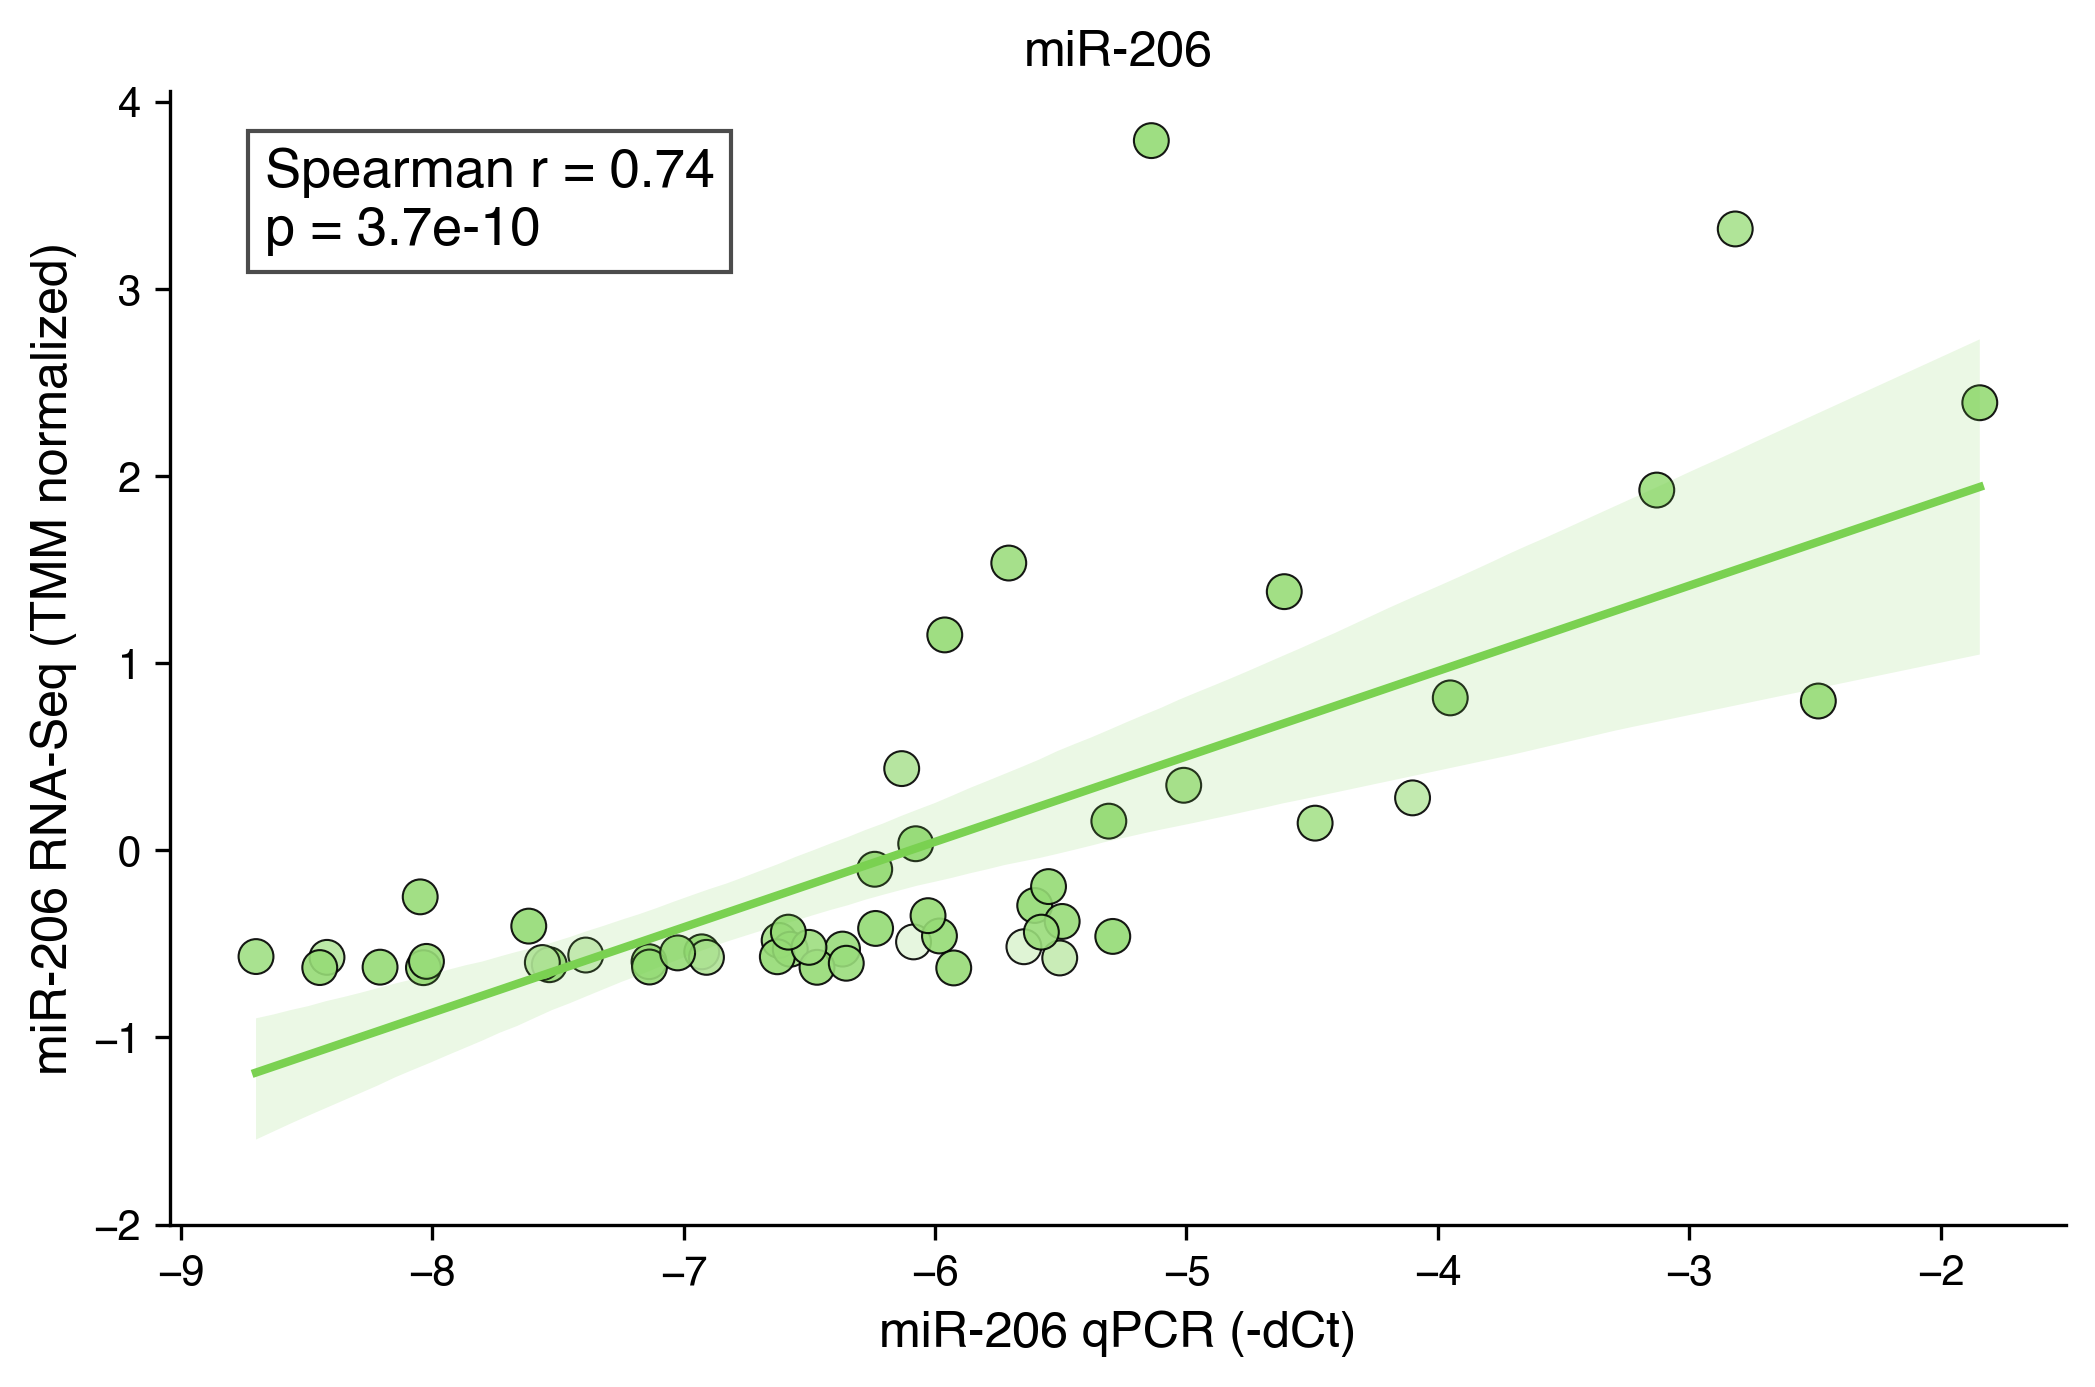

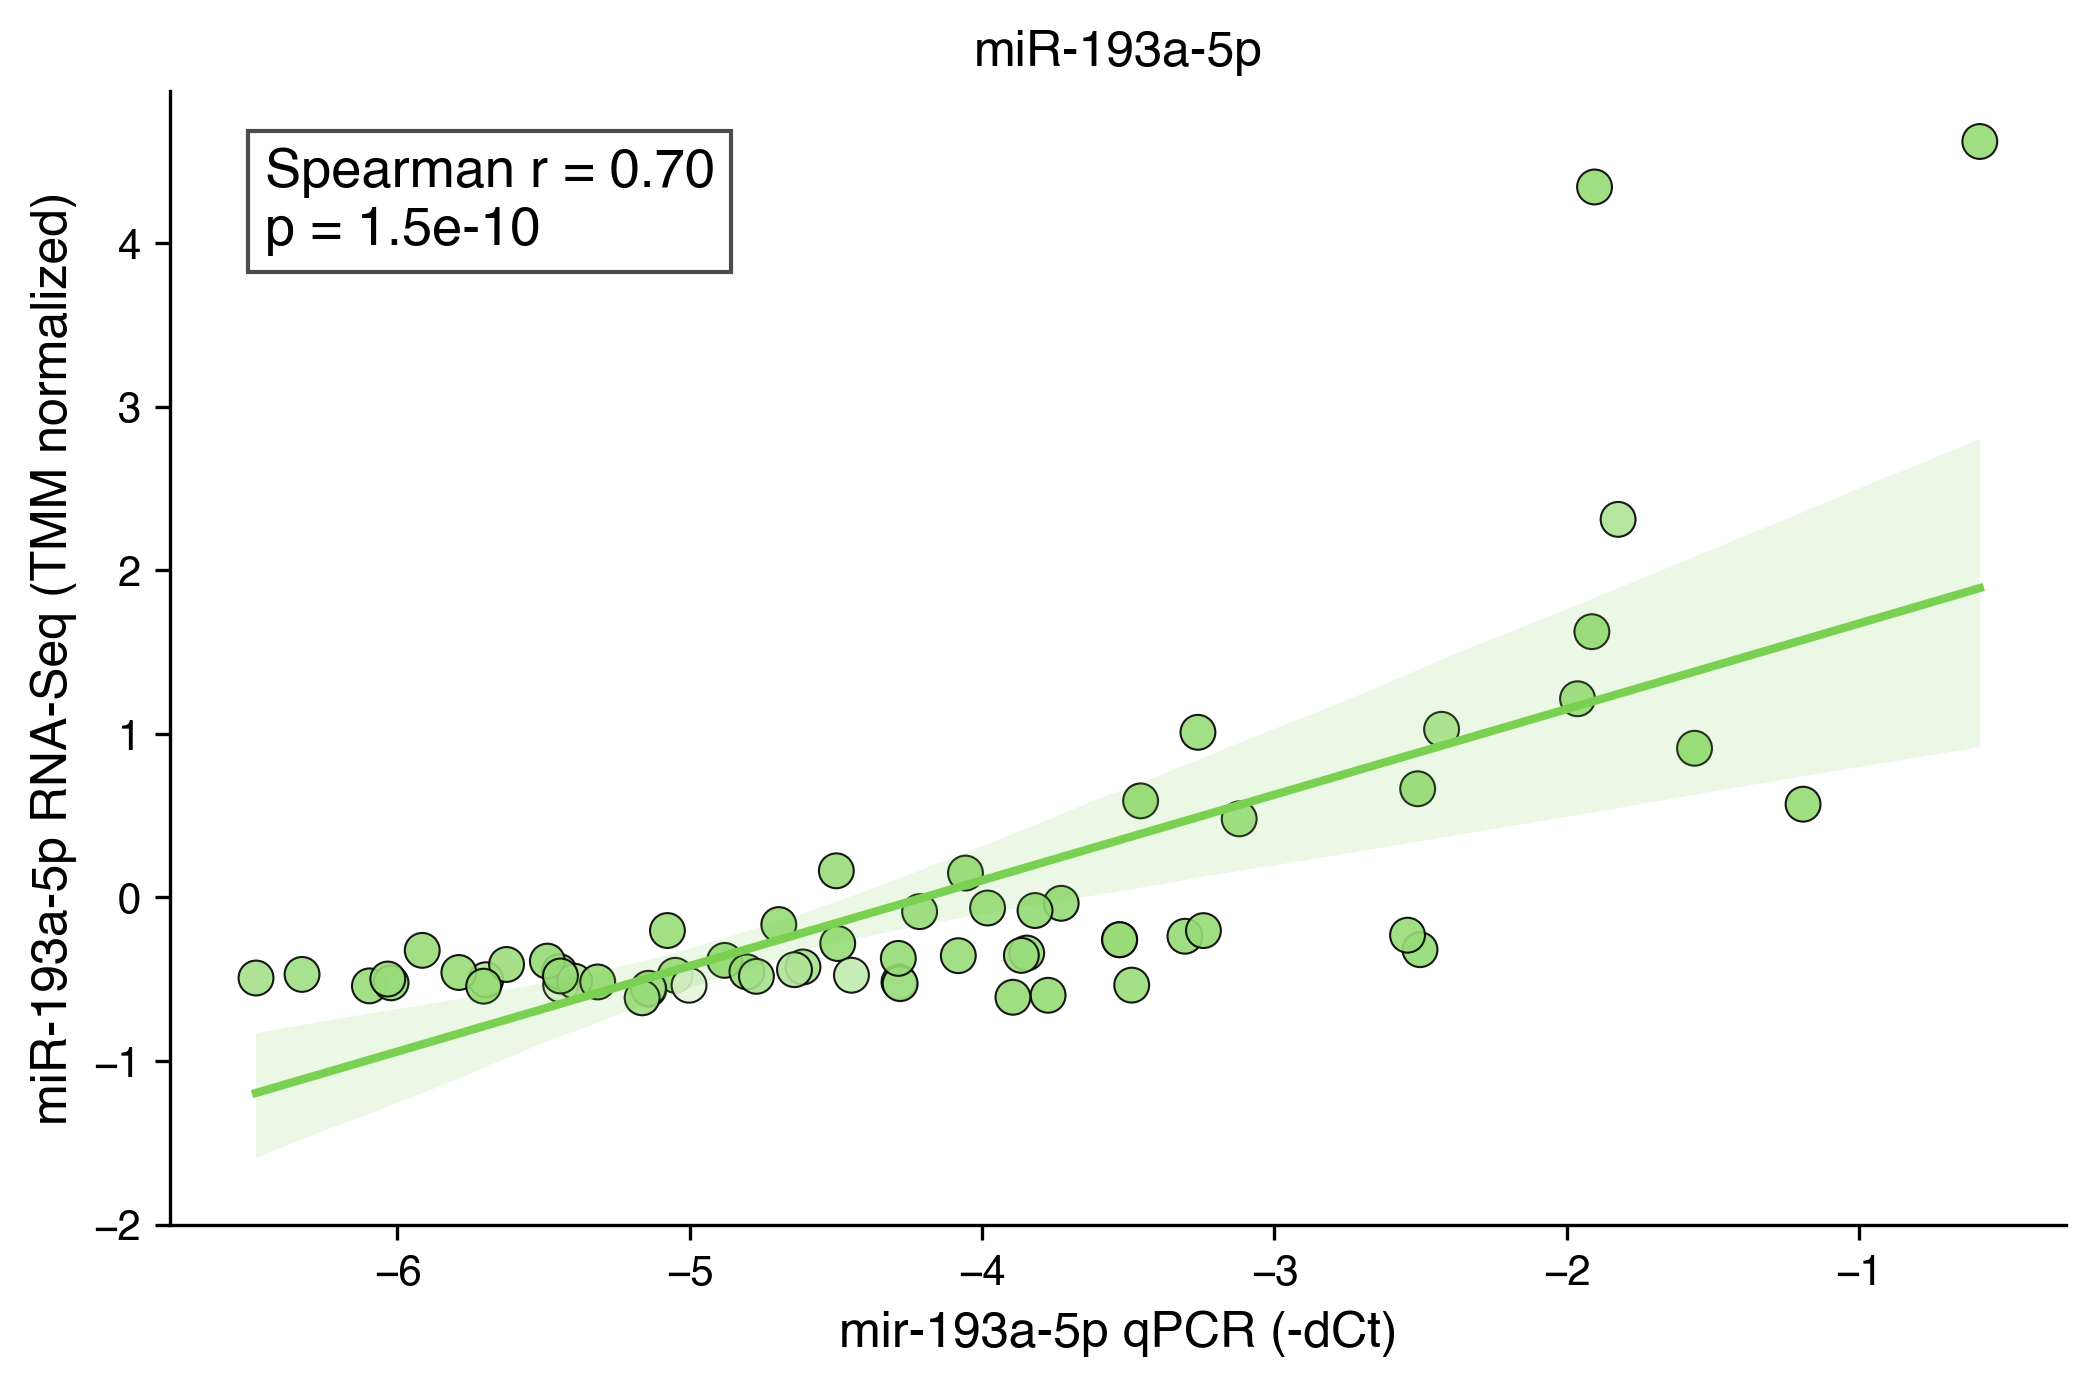

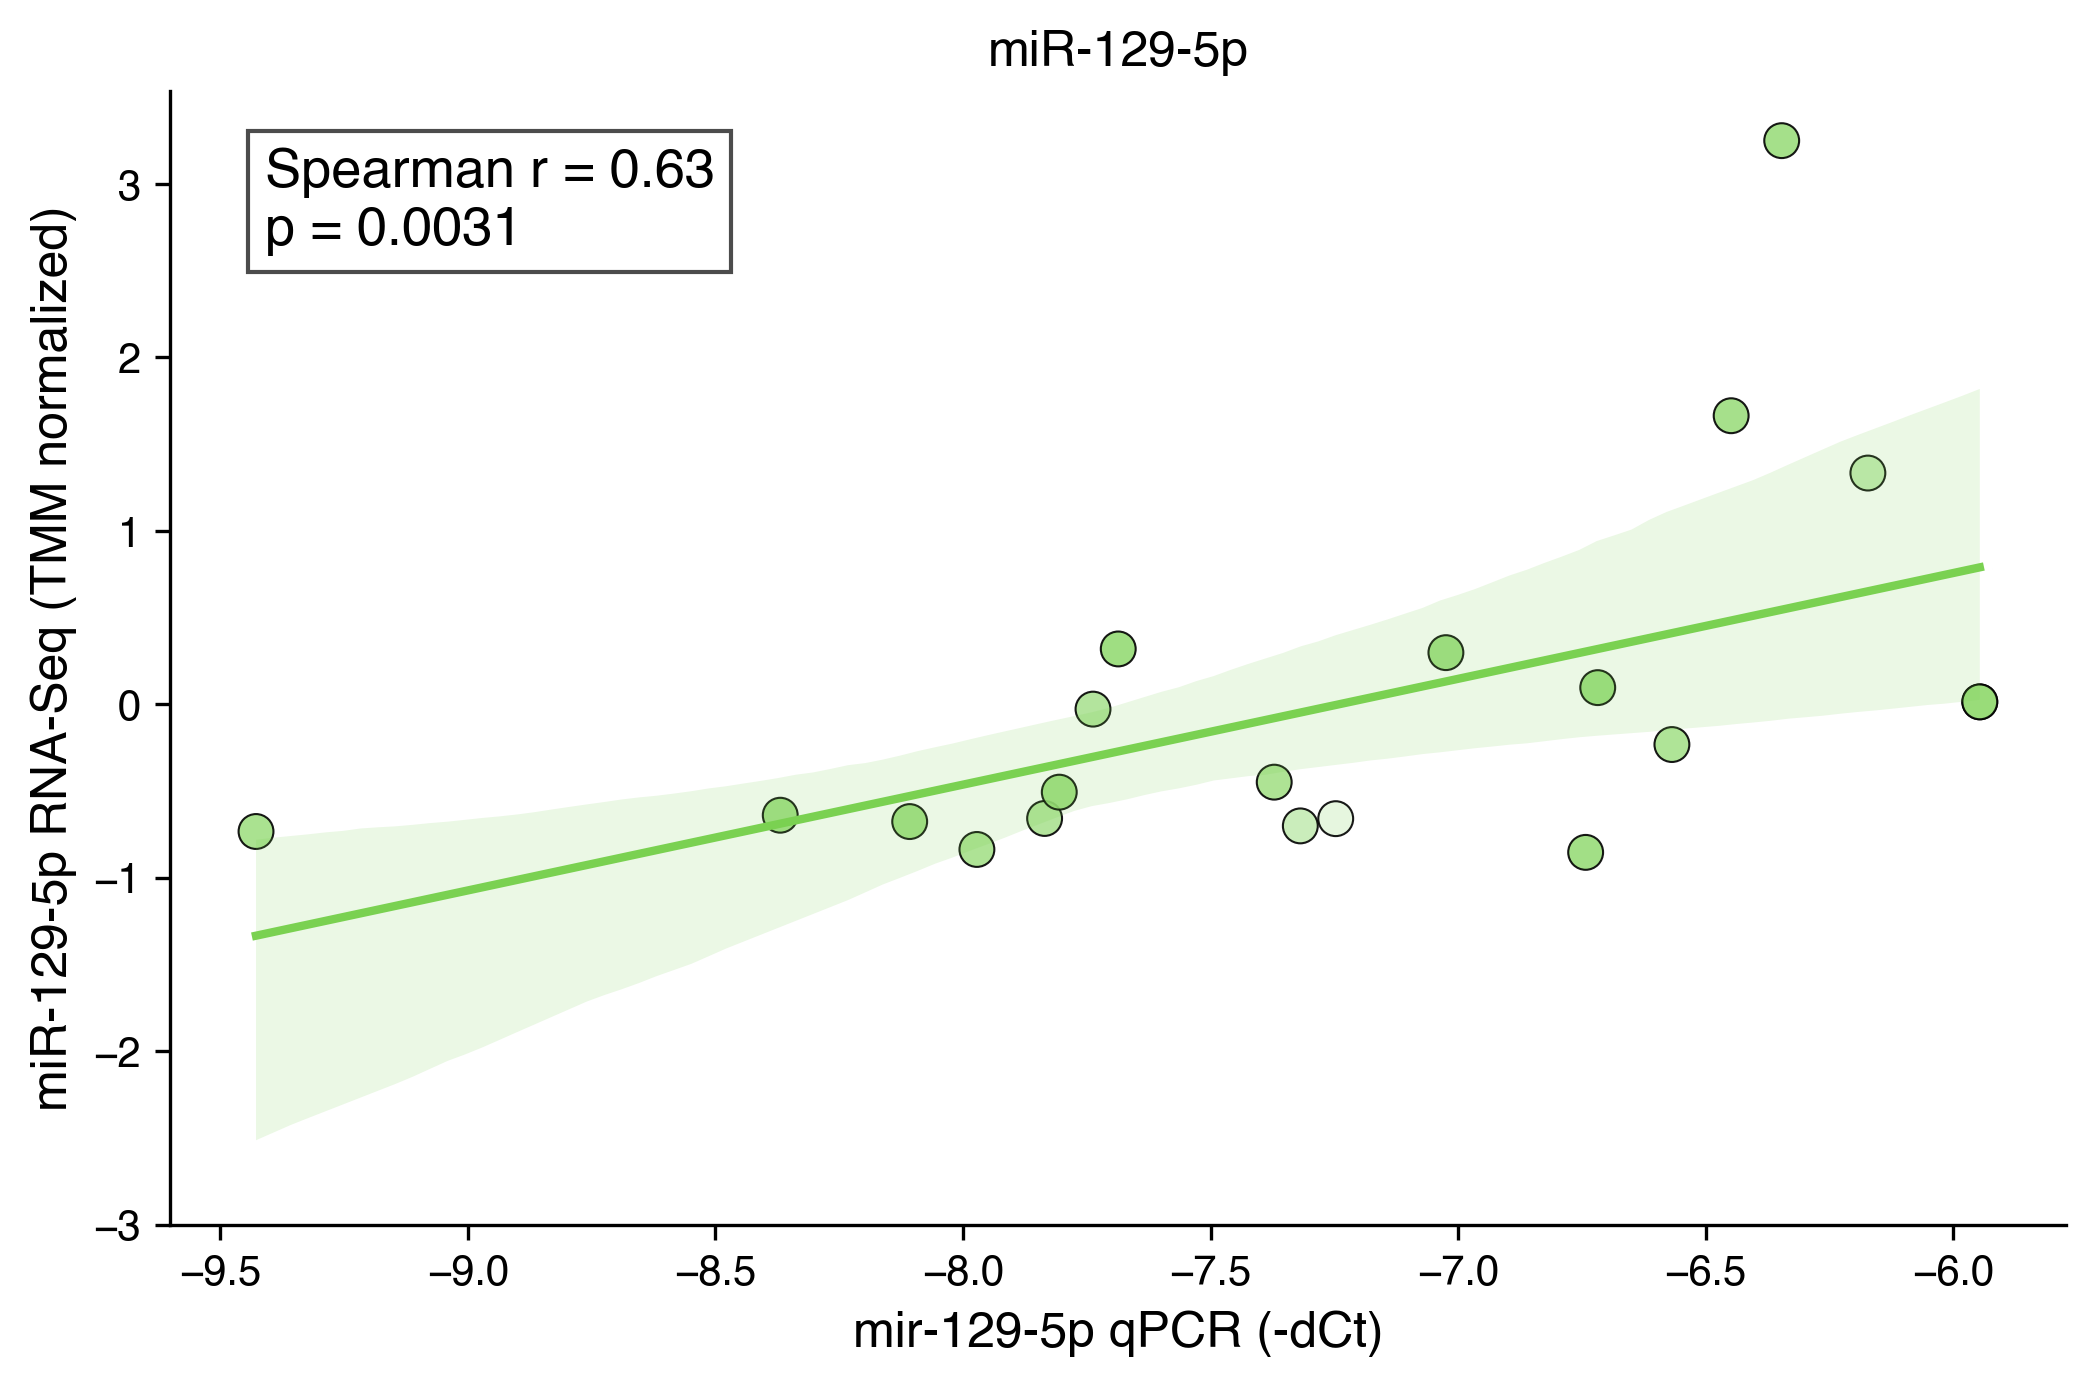

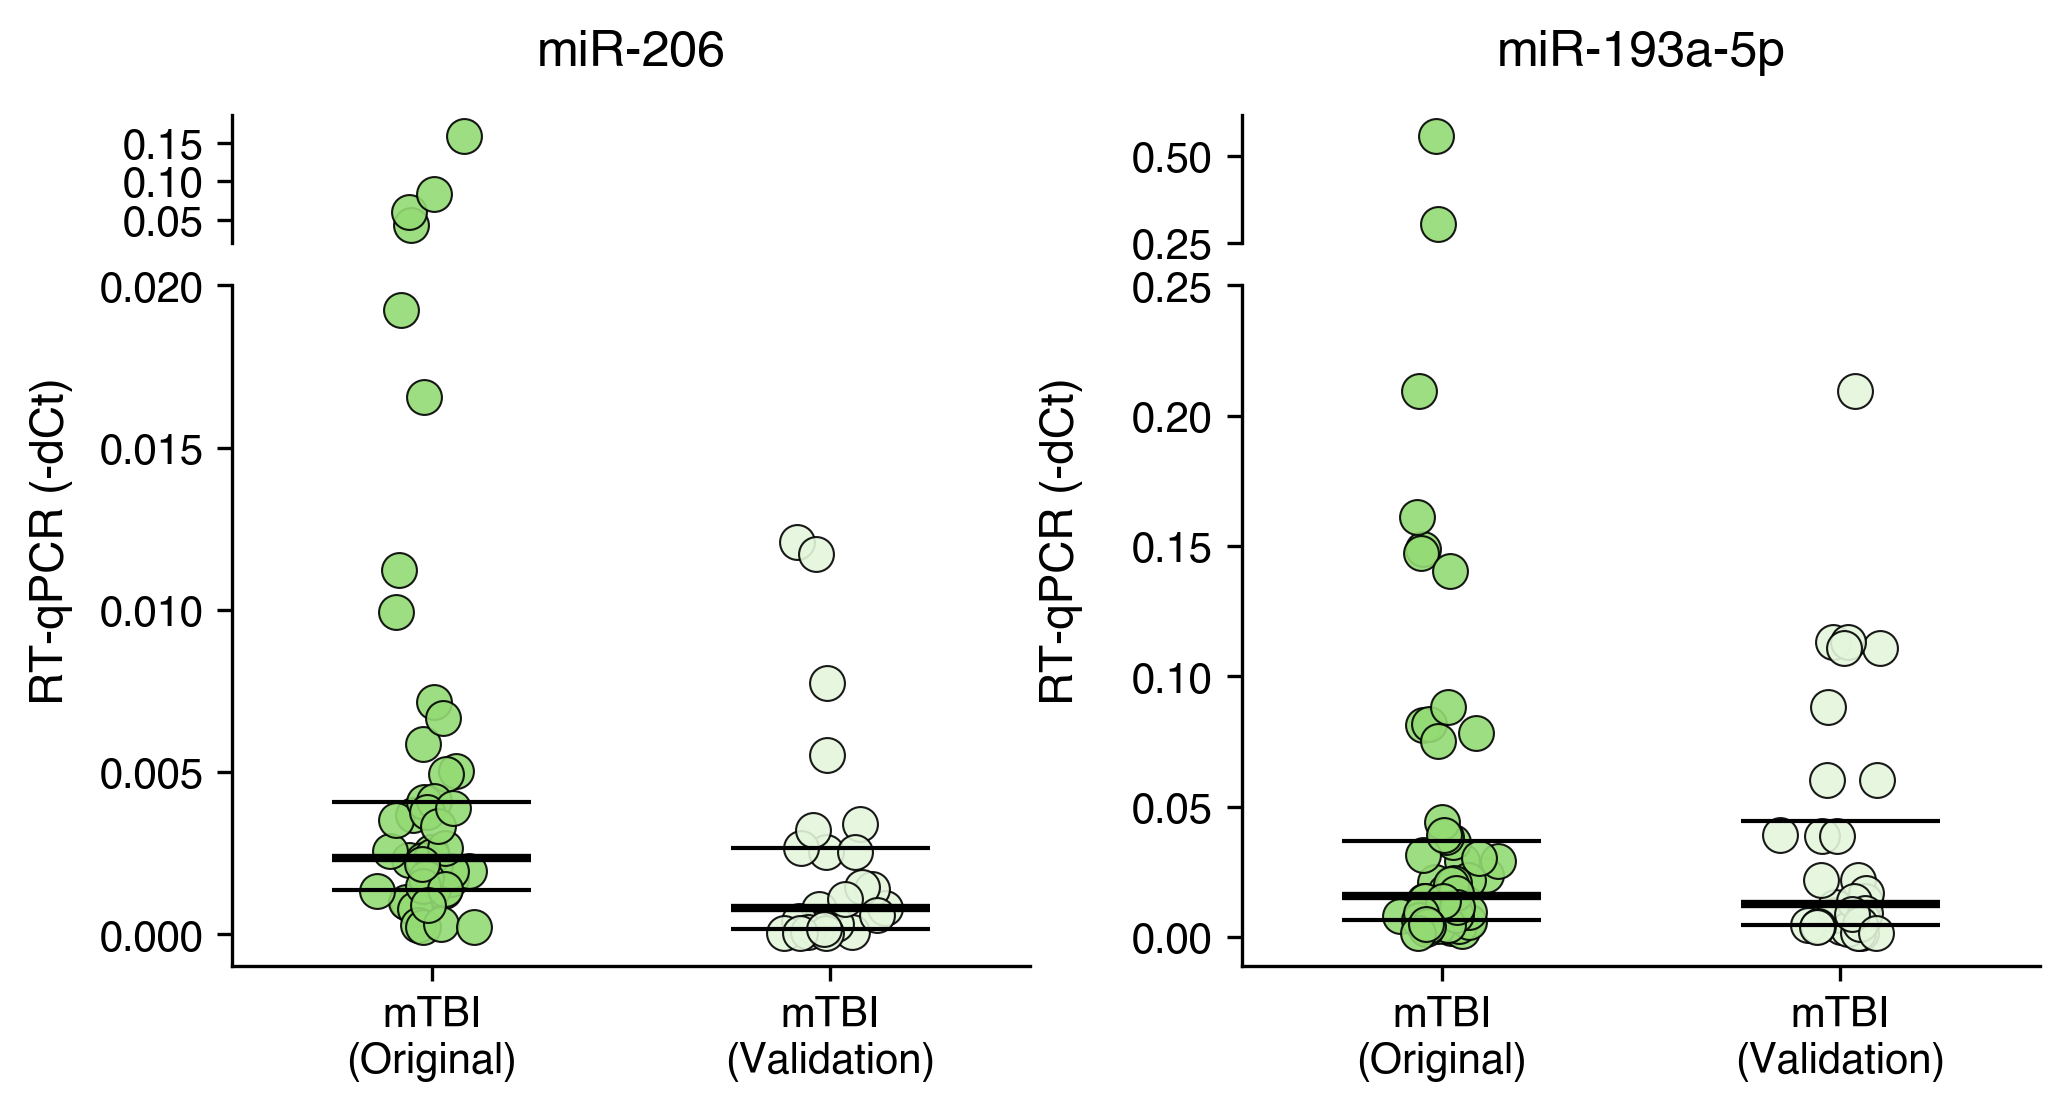

In [ ]:
# corr_data_129 = analysis_data.loc[(analysis_data['hsa_mir_129_log'].notna()) & (analysis_data['hsa_mir_129_rc'].notna())]
corr_data = analysis_data.iloc[0:64, :]
corr_analysis('hsa_mir_206_log', 'hsa-miR-206_dx', corr_data, lim=6000, ylim=-2, labels={'x': 'miR-206 qPCR (-dCt)', 'y': 'miR-206 RNA-Seq (TMM normalized)', 'title': 'miR-206'}, save=False, savelocation = r'/users/koen_phd/Documents/phd/biomarkers/mirna/figures/val_corr_mir_206.svg', figsize_mm=(180, 120))
corr_analysis('hsa_mir_193_log', 'hsa-miR-193a-5p_dx', corr_data, lim=60000, ylim=-2, labels={'x': 'mir-193a-5p qPCR (-dCt)', 'y': 'miR-193a-5p RNA-Seq (TMM normalized)', 'title': 'miR-193a-5p'}, save=False, savelocation = r'/users/koen_phd/Documents/phd/biomarkers/mirna/figures/val_corr_mir_193a.svg', figsize_mm=(180, 120))
corr_analysis('hsa_mir_129_log', 'hsa-miR-129-5p_dx', corr_data, lim=500, ylim=-3, labels={'x': 'mir-129-5p qPCR (-dCt)', 'y': 'miR-129-5p RNA-Seq (TMM normalized)', 'title': 'miR-129-5p'}, save=False, savelocation = r'/users/koen_phd/Documents/phd/biomarkers/mirna/figures/val_corr_mir_129.svg', figsize_mm=(180, 120))

break_thresholds = {
    'hsa_mir_206': 0.02,
    'hsa_mir_193': 0.25
}

mtbi_org = analysis_data.iloc[0:64, :].loc[(analysis_data['group'] == 1)]
mtbi_val = analysis_data.iloc[64:, :].loc[(analysis_data['group'] == 1)]

plotting_dataframes = [mtbi_org, mtbi_val]
plotting_dataframe_names = ['mTBI\n(Original)', 'mTBI\n(Validation)']

margin_dict = {'left': 0.1, 'right': 0.05, 'top': 0.05, 'bottom': 0.05, 'h_spacing': 0.1, 'v_spacing': 0.1}

fig, axes = plot_boxplot(plotting_dataframes, plotting_dataframe_names, ['hsa_mir_206', 'hsa_mir_193'], margin_dict=margin_dict, figsize=(180, 80), break_thresholds=break_thresholds, titles=['miR-206', 'miR-193a-5p'], y_labels=['RT-qPCR (-dCt)', 'RT-qPCR (-dCt)'], save=False, save_location = r'/users/koen_phd/Documents/phd/biomarkers/mirna/figures/boxplot_validation.svg')